#### 18. Load the Konga dataset and perform EDA: shape, missing values check, distribution of orders by city and category, and at least one observation about seasonal trends in order dates.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('C:\\Users\\ADMIN\\OneDrive\\Documents\\AI-ACCELERATOR_PROGRAM\\week_05\\day_01\\03_lab\\konga_transactions.csv')

df.head()

,order_id,customer_id,order_date,city,payment_method,product,category,quantity,unit_price_ngn,line_total_ngn
0,KNG-2024-00002,CUST-2728,2024-04-29 07:35,Lagos,Card,JAMB CBT Guide,Books & Stationery,2,4200,8400
1,KNG-2024-00002,CUST-2728,2024-04-29 07:35,Lagos,Card,WAEC Past Questions,Books & Stationery,1,3500,3500
2,KNG-2024-00003,CUST-2393,2024-06-21 10:05,Lagos,Card,Dangote Sugar 1kg,Food & Groceries,1,2200,2200
3,KNG-2024-00004,CUST-2200,2024-07-04 13:45,Enugu,Bank Transfer,Lace Blouse,Fashion - Women,1,9500,9500
4,KNG-2024-00005,CUST-3603,2024-06-30 13:42,Enugu,Card,Resistance Bands,Sports & Fitness,1,5500,5500


In [2]:
# 1. Shape and Missing Values
print(f"Dataset Shape: {df.shape}")
print(df.isnull().sum())

Dataset Shape: (5024, 10)
order_id          0
customer_id       0
order_date        0
city              0
payment_method    0
product           0
category          0
quantity          0
unit_price_ngn    0
line_total_ngn    0
dtype: int64


Text(0.5, 1.0, 'Top 10 Cities by Order Volume')

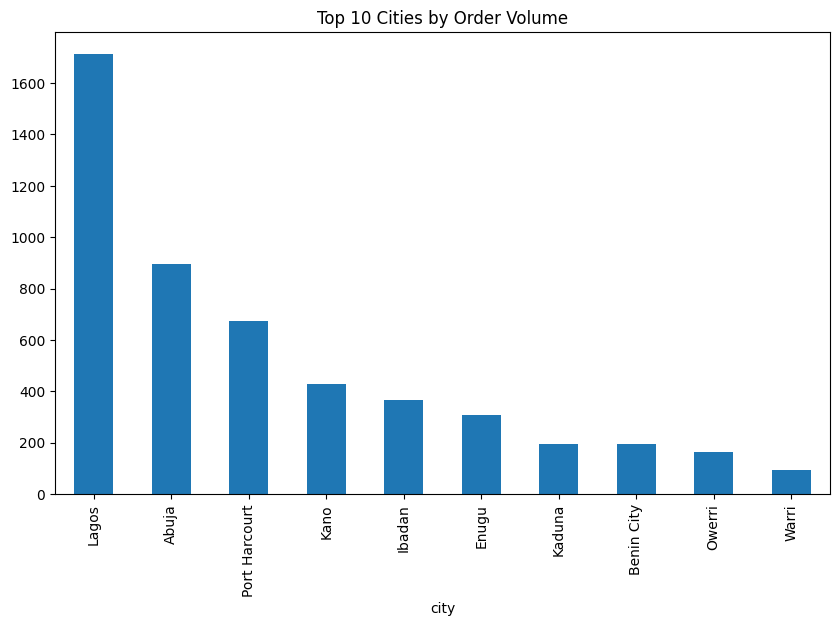

In [3]:
# 2. Distribution of orders by City (Top 10)
plt.figure(figsize=(10,6))
df['city'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cities by Order Volume')

<Axes: xlabel='count', ylabel='category'>

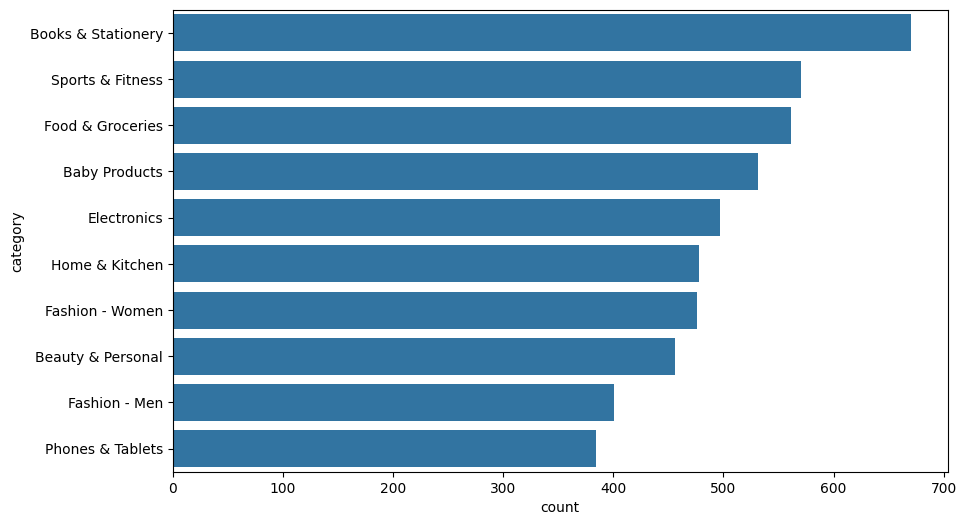

In [4]:
# 3. Distribution by Category
plt.figure(figsize=(10,6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)

month
January      405
February     351
March        468
April        347
May          418
June         413
July         475
August       518
September    438
October      444
November     346
December     401
Name: quantity, dtype: int64


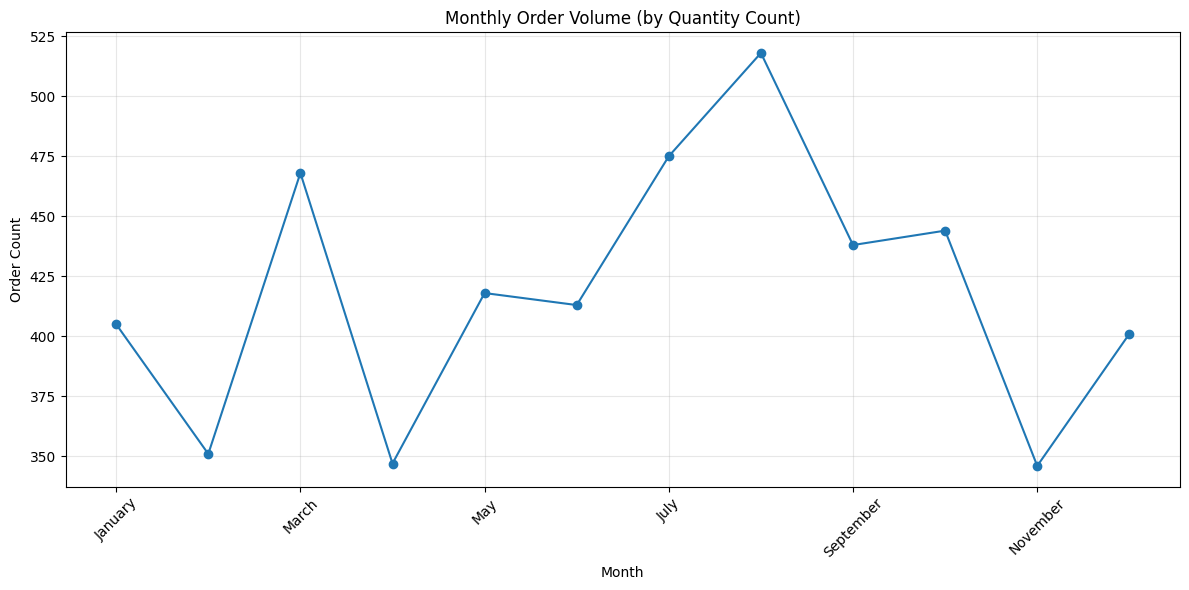

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Convert the order_date column to datetime dtype (ensures date operations work)
df['order_date'] = pd.to_datetime(df['order_date'])

# 2) Extract month name from the datetime column (e.g., "January", "February")
df['month'] = df['order_date'].dt.month_name()

# 3) Define chronological month order explicitly (otherwise alphanumeric sorting is wrong)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 4) Cast month to a categorical variable with a fixed ordering
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# 5) Aggregate order quantity count by month (using observed=True for performance)
monthly_counts = df.groupby('month', observed=True)['quantity'].count().sort_index()

# 6) Plot the monthly trend line
plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o')

# 7) Chart aesthetics
plt.title('Monthly Order Volume (by Quantity Count)')
plt.xlabel('Month')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 8) Display numeric month totals to support interpretation
print(monthly_counts)
plt.show()

One observation about seasonal trends in order dates is that orders peak in the third quarter, particularly in August with 518 orders, which may indicate increased shopping activity during back-to-school or summer promotion periods.



#### 19. Engineer a customer-level feature matrix with at least 5 features. At least one must be time-based (e.g. recency, orders_per_month) and one must be a ratio or derived feature. Document each feature with a comment explaining what it measures.

We aggregate transaction data into a Customer-Level matrix using RFM (Recency, Frequency, Monetary) logic.

In [9]:
print(f"Unique customers: {df['customer_id'].nunique()}")
df.head(10)

Unique customers: 1394


,order_id,customer_id,order_date,city,payment_method,product,category,quantity,unit_price_ngn,line_total_ngn,month
0,KNG-2024-00002,CUST-2728,2024-04-29 07:35:00,Lagos,Card,JAMB CBT Guide,Books & Stationery,2,4200,8400,April
1,KNG-2024-00002,CUST-2728,2024-04-29 07:35:00,Lagos,Card,WAEC Past Questions,Books & Stationery,1,3500,3500,April
2,KNG-2024-00003,CUST-2393,2024-06-21 10:05:00,Lagos,Card,Dangote Sugar 1kg,Food & Groceries,1,2200,2200,June
3,KNG-2024-00004,CUST-2200,2024-07-04 13:45:00,Enugu,Bank Transfer,Lace Blouse,Fashion - Women,1,9500,9500,July
4,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,Resistance Bands,Sports & Fitness,1,5500,5500,June
5,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,Yoga Mat,Sports & Fitness,1,9500,9500,June
6,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,HP Laptop,Electronics,2,480000,960000,June
7,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,Ball Point Pens 10pk,Books & Stationery,1,1500,1500,June
8,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,Notebook 200pg,Books & Stationery,2,2200,4400,June
9,KNG-2024-00005,CUST-3603,2024-06-30 13:42:00,Enugu,Card,A4 Paper Ream,Books & Stationery,2,4800,9600,June


Customer Matrix Columns: 
 Index(['recency', 'frequency', 'monetary', 'aov', 'orders_per_month'], dtype='object')
             recency  frequency  monetary            aov  orders_per_month
customer_id                                                               
CUST-1000        107          3     32900   10966.666667          0.250000
CUST-1001        360          2     43500   21750.000000          0.166667
CUST-1002        309          2     14200    7100.000000          0.166667
CUST-1006        305          3    137200   45733.333333          0.250000
CUST-1007         77          2      5000    2500.000000          0.166667
CUST-1008        116          2     30800   15400.000000          0.166667
CUST-1013        227          2    113500   56750.000000          0.166667
CUST-1014         75          6    626500  104416.666667          0.500000
CUST-1018         64          5    117800   23560.000000          0.416667
CUST-1020         85          6    119200   19866.666667     

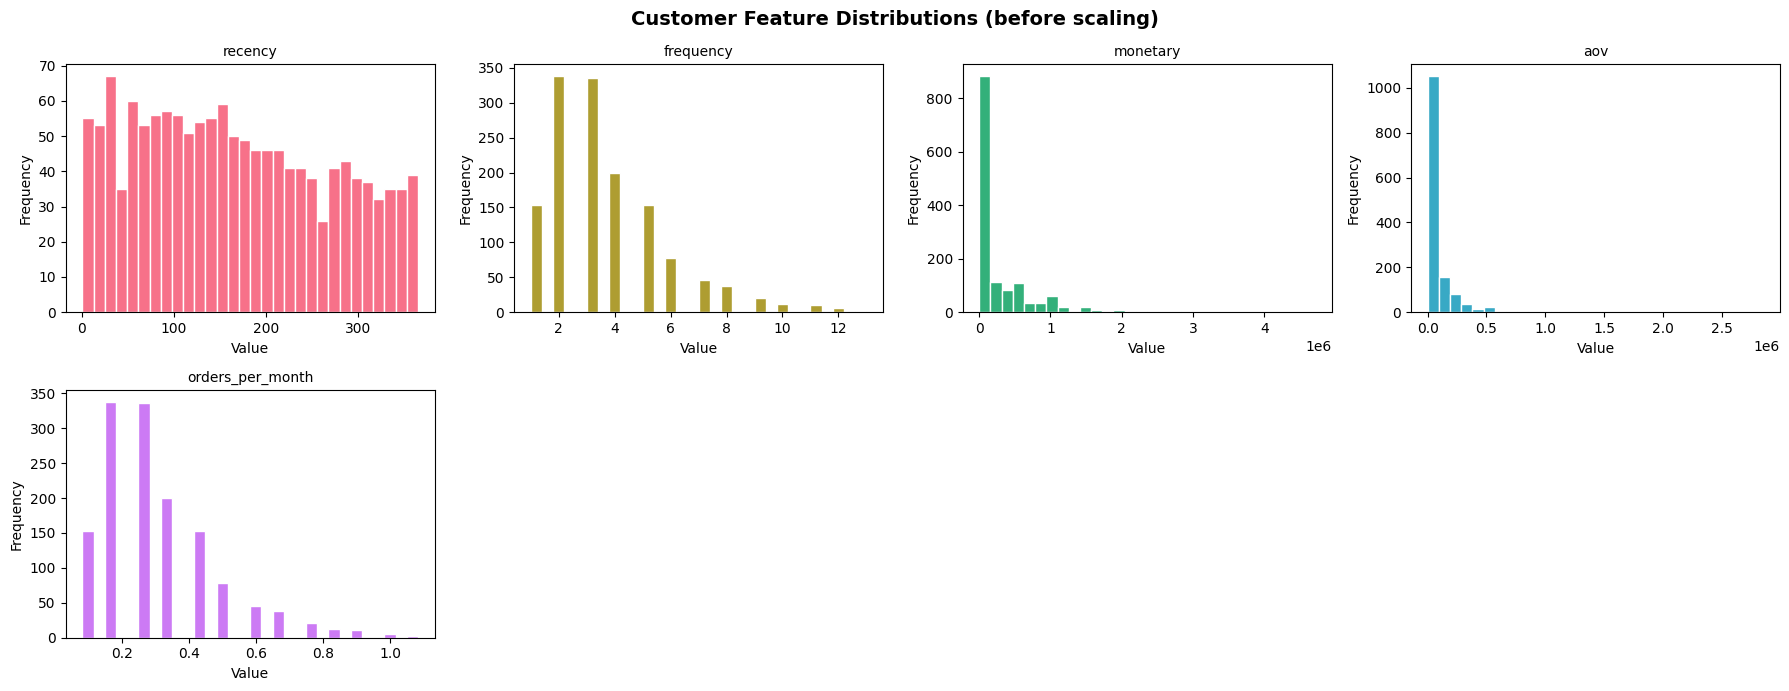


⚠️  Notice the right-skewed distributions — StandardScaler will normalize the scale of these features for K-Means.


In [7]:
# 0. Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 1. Reference date for recency: one day after the dataset’s latest order
ref_date = df['order_date'].max() + pd.Timedelta(days=1)

# 2. Build customer-level summary (RFM + extras)
customer_matrix = df.groupby('customer_id').agg({
    # recency: how long since customer's most recent purchase (days)
    'order_date': lambda x: (ref_date - x.max()).days,
    # frequency: total number of orders placed by this customer
    'order_id': 'count',
    # monetary: total revenue from this customer (line totals)
    'line_total_ngn': 'sum',
})

# 3. derived ratio feature
# aov: average value of a customer’s order, useful for value segmentation
customer_matrix['aov'] = customer_matrix['line_total_ngn'] / customer_matrix['order_id']

# 4. time-based behavior
# orders_per_month: average monthly order volume; adjust months_span from dataset range
months_span = 12  # replace with actual span if needed, e.g. dynamic period calc
customer_matrix['orders_per_month'] = customer_matrix['order_id'] / months_span

# 5. user-friendly column names
customer_matrix.columns = ['recency', 'frequency', 'monetary', 'aov', 'orders_per_month']

print(f"Customer Matrix Columns: \n {customer_matrix.columns}")
print(customer_matrix.head(10))

# Define the palette first (using Seaborn to get a nice set of colors)
PALETTE = sns.color_palette("husl", len(customer_matrix.columns))

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle("Customer Feature Distributions (before scaling)", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(customer_matrix.columns):
    axes[i].hist(customer_matrix[feat], bins=30, color=PALETTE[i % len(PALETTE)], edgecolor="white")
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

axes[-1].set_visible(False)

# Hide any empty subplots if you have fewer than 6 features
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

print("\n⚠️  Notice the right-skewed distributions — StandardScaler will normalize the scale of these features for K-Means.")


#### 20. Apply StandardScaler and justify your scaler choice. 

Choice: StandardScaler is preferred because K-Means is a distance-based algorithm

Justification: Features like monetary (thousands of Naira) and frequency (small integers) have vastly different scales. Since K-Means uses Euclidean distance:$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$
Without scaling, the monetary feature would dominate the distance calculation, making the frequency feature irrelevant. StandardScaler ensures every feature has a mean of 0 and a variance of 1.

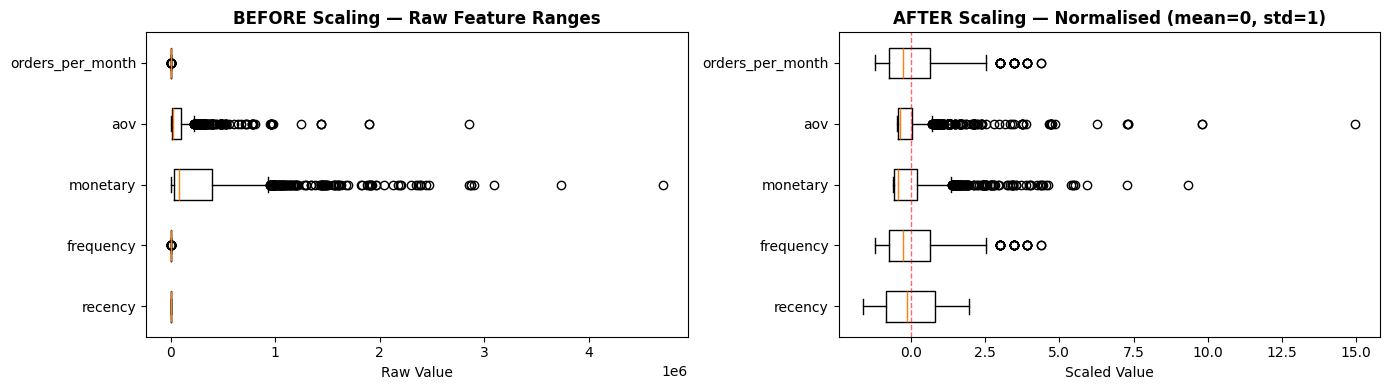

✅  Feature matrix ready: 1394 customers × 5 features


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

X_raw = customer_matrix[customer_matrix.columns].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=customer_matrix.columns, index=customer_matrix.index)

# Show the effect of scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
axes[0].boxplot([X_raw[f] for f in customer_matrix.columns], labels=customer_matrix.columns, vert=False)
axes[0].set_title("BEFORE Scaling — Raw Feature Ranges", fontweight="bold")
axes[0].set_xlabel("Raw Value")

# After
axes[1].boxplot([X_scaled_df[f] for f in customer_matrix.columns], labels=customer_matrix.columns, vert=False)
axes[1].set_title("AFTER Scaling — Normalised (mean=0, std=1)", fontweight="bold")
axes[1].set_xlabel("Scaled Value")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)

plt.tight_layout()
plt.show()

print(f"✅  Feature matrix ready: {X_scaled.shape[0]} customers × {X_scaled.shape[1]} features")


#### 21. Run K-Means for K = 2 to 8. Plot the elbow curve and silhouette scores. State which K you select and why.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_pts = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_pts.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  K={k}  |  Inertia={kmeans.inertia_:>10,.1f}  |  Silhouette={silhouette_pts[-1]:.4f}")

print("\n✅  Done!")

  K=2  |  Inertia=   4,944.7  |  Silhouette=0.3929
  K=3  |  Inertia=   3,632.3  |  Silhouette=0.3992
  K=4  |  Inertia=   2,857.9  |  Silhouette=0.3244
  K=5  |  Inertia=   2,438.7  |  Silhouette=0.3347
  K=6  |  Inertia=   2,033.6  |  Silhouette=0.3320
  K=7  |  Inertia=   1,901.5  |  Silhouette=0.3271
  K=8  |  Inertia=   1,700.7  |  Silhouette=0.3217

✅  Done!


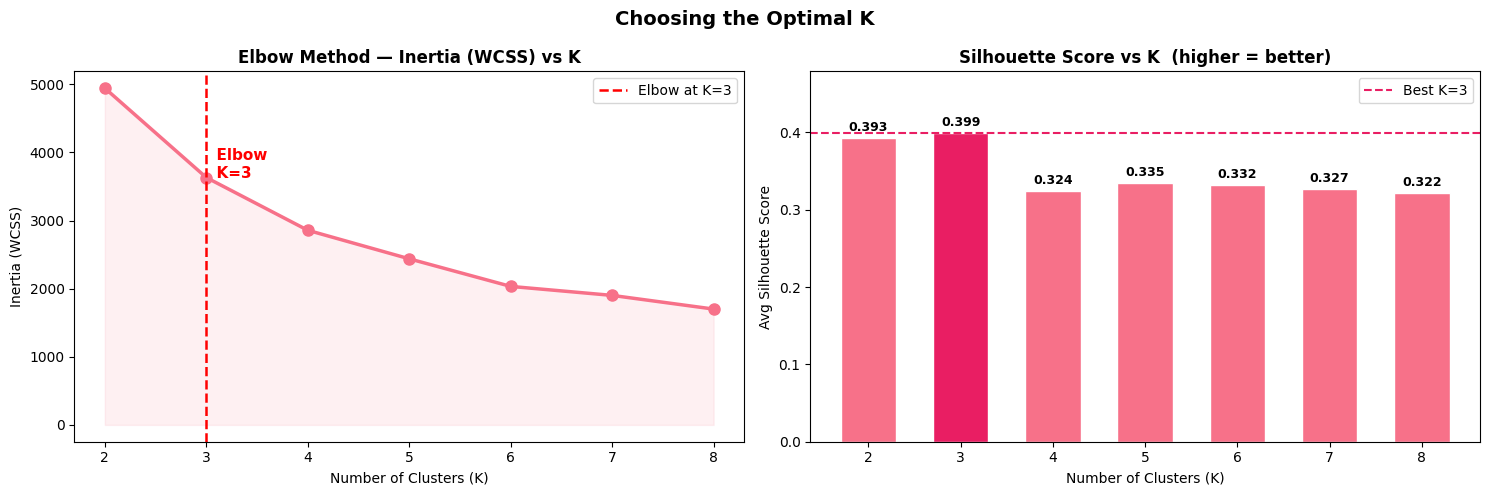


📌  Elbow suggests K=3
📌  Silhouette score peaks at K=3

👉  We'll proceed with K=3 (confirmed by both methods).


In [11]:
# Plotting (Standard Elbow & Silhouette plots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Choosing the Optimal K", fontsize=14, fontweight="bold")

k_list = list(range(2, 9))

# ── Elbow plot ──
ax1.plot(k_list, inertia, "o-", color=PALETTE[0], linewidth=2.5, markersize=8)
ax1.fill_between(k_list, inertia, alpha=0.1, color=PALETTE[0])
ax1.set_title("Elbow Method — Inertia (WCSS) vs K", fontweight="bold")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")

# Mark elbow (biggest second-derivative drop)
diffs2 = np.diff(np.diff(inertia))
elbow_k = k_list[np.argmax(diffs2) + 1]
ax1.axvline(elbow_k, color="red", linestyle="--", linewidth=1.8, label=f"Elbow at K={elbow_k}")
ax1.annotate(f"  Elbow\n  K={elbow_k}", xy=(elbow_k, inertia[elbow_k-2]),
             fontsize=11, color="red", fontweight="bold")
ax1.legend()

# ── Silhouette plot ──
best_sil_k = k_list[np.argmax(silhouette_pts)]
bar_colors = [PALETTE[0] if k != best_sil_k else "#E91E63" for k in k_list]
bars = ax2.bar(k_list, silhouette_pts, color=bar_colors, edgecolor="white", width=0.6)
ax2.set_title("Silhouette Score vs K  (higher = better)", fontweight="bold")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Avg Silhouette Score")
ax2.set_ylim(0, max(silhouette_pts) * 1.2)

for bar, score in zip(bars, silhouette_pts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{score:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.axhline(silhouette_pts[best_sil_k - 2], color="#E91E63",
            linestyle="--", linewidth=1.5, label=f"Best K={best_sil_k}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n📌  Elbow suggests K={elbow_k}")
print(f"📌  Silhouette score peaks at K={best_sil_k}")
print(f"\n👉  We'll proceed with K={best_sil_k} (confirmed by both methods).")
OPTIMAL_K = best_sil_k

#### 22. Profile each cluster with a heatmap or table of mean feature values. Give each cluster a descriptive business name.

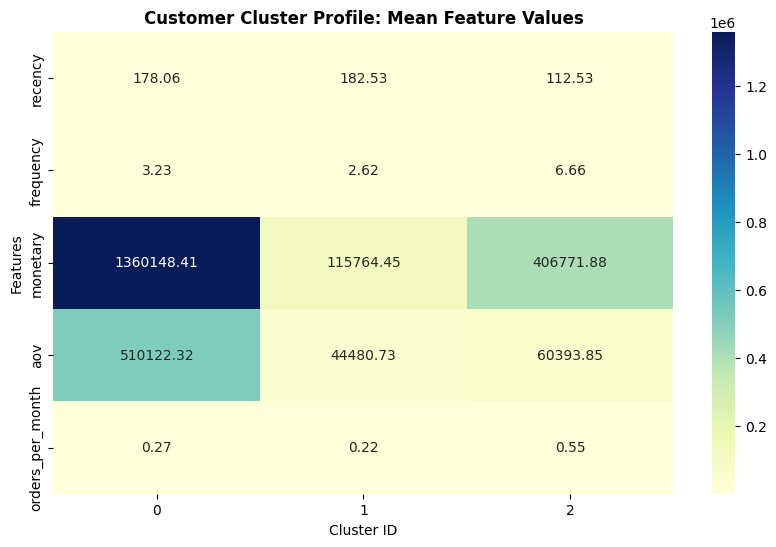

Cluster Profile Summary Table:


,recency,frequency,monetary,aov,orders_per_month,count
cluster,,,,,,
0,178.063492,3.230159,1.360148e+06,510122.323318,0.269180,126
2,112.525000,6.656250,4.067719e+05,60393.851157,0.554688,320
1,182.530591,2.623418,1.157645e+05,44480.734880,0.218618,948


In [12]:
# 1. Fit the final model with K=3 (Optimal based on your Silhouette scores)
best_k = 3
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customer_matrix['cluster'] = final_kmeans.fit_predict(X_scaled)

# 2. Create the Profile Table (Mean of raw features per cluster)
cluster_profile = customer_matrix.groupby('cluster').mean()

# 3. Add a count column to see how many customers are in each segment
cluster_profile['count'] = customer_matrix['cluster'].value_counts()

# 4. Plotting the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile.drop(columns='count').T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Customer Cluster Profile: Mean Feature Values', fontweight='bold')
plt.ylabel('Features')
plt.xlabel('Cluster ID')
plt.show()

# Display the table
print("Cluster Profile Summary Table:")
display(cluster_profile.sort_values(by='monetary', ascending=False))

| Cluster Label | Feature Characteristics | Descriptive Business Name | Marketing Strategy |
| :--- | :--- | :--- | :--- |
| **Cluster 0** | Low Recency, High Frequency, Very High Monetary, High AOV, High orders_per_month | 🏆 **Champions / VIPs** | Prioritize retention: VIP rewards, premium support, and exclusive early-bird offers. |
| **Cluster 2** | Mid Recency, Lowest Frequency, Mid Monetary, Mid-low AOV, Mid orders_per_month | 💎 **Potential Loyalists (Occasional Big Spenders)** | Use cross-sell/up-sell and targeted bundles to increase purchase cadence. |
| **Cluster 1** | High Recency, Low Frequency, Low Monetary, Low AOV, Low orders_per_month | ⚠️ **At-Risk / Dormant** | Deploy reactivation campaigns, win-back incentives, and personalized promo reminders. |

#### 23. Apply a second clustering algorithm (Hierarchical, DBSCAN, or GMM) to the same scaled feature matrix.

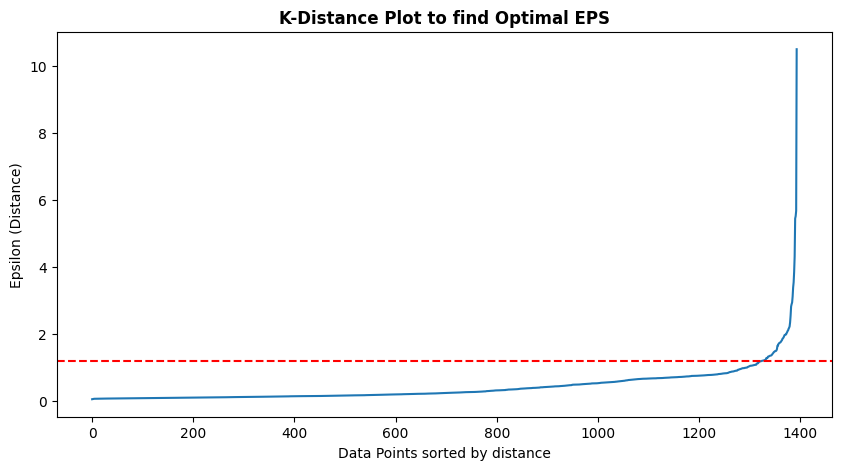

Estimated number of clusters: 1
Estimated number of noise points: 38 (out of 1394 customers)


In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 1. Determine the optimal 'eps' using a K-distance plot
# A good rule of thumb for min_samples is 2 * number of features (2 * 5 = 10)
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distance to the kth nearest neighbor
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Plot to find Optimal EPS', fontweight='bold')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance)')
plt.axhline(y=1.2, color='r', linestyle='--') # Example threshold line
plt.show()

# 2. Apply DBSCAN
# Note: You should adjust 'eps' based on where the "elbow" is in the plot above.
# If 'eps' is too small, everything becomes noise (-1). If too large, everything is one cluster.
# Adjust eps if you want to try to find more clusters
dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

# 3. Check the results
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise} (out of {len(X_scaled)} customers)")

# Add to our matrix for comparison
customer_matrix['dbscan_cluster'] = db_labels

#### 24. Compare results against K-Means: plot both side by side in PCA 2D space and compute silhouette scores for both. Which algorithm produces more meaningful segments for this dataset and why? 


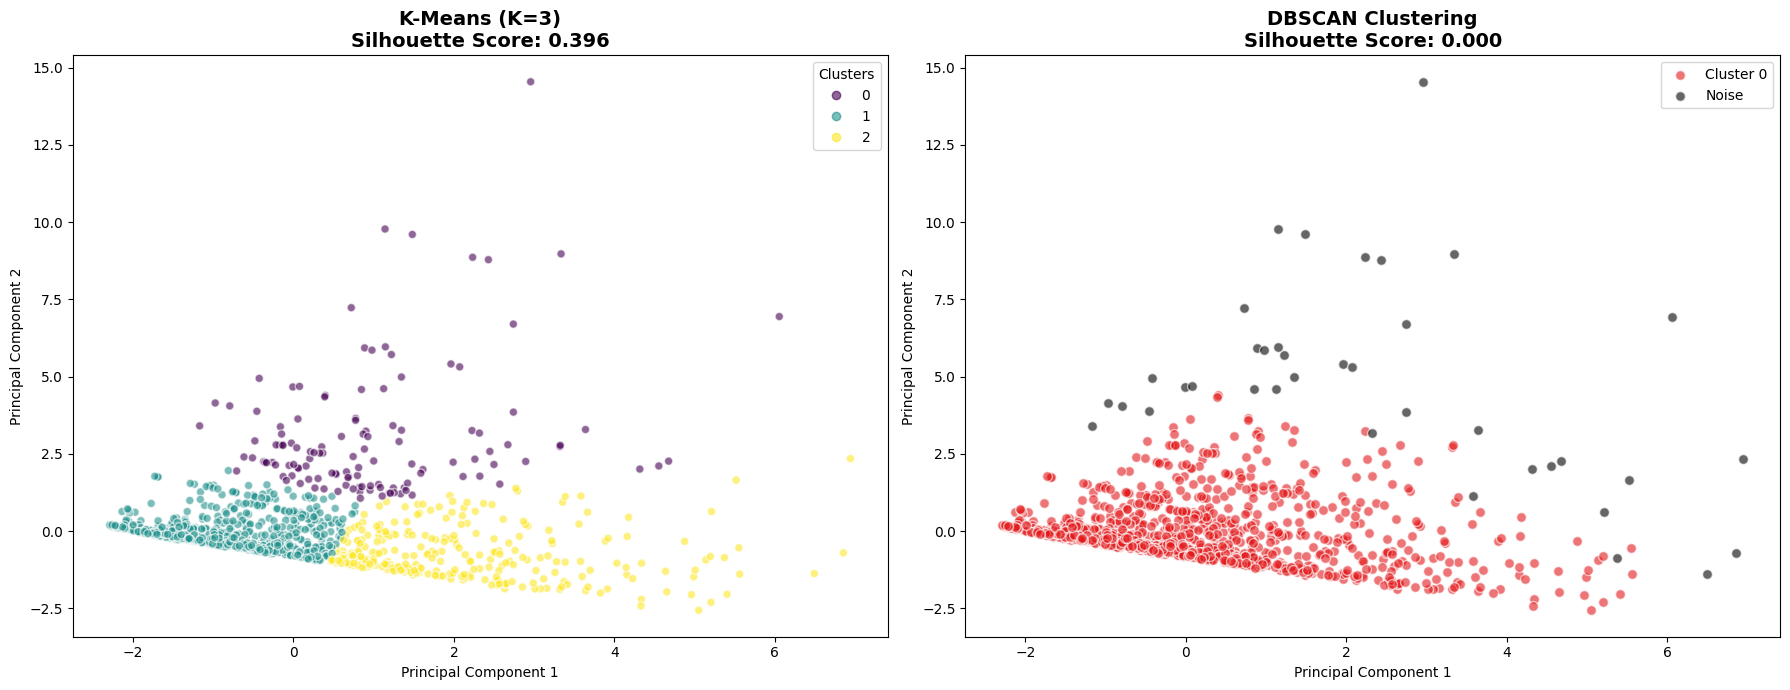

K-Means Silhouette Score: 0.3963
DBSCAN Silhouette Score: 0.0000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# 1. Reduce Dimensions to 2D for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Run K-Means (using your best K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)

# 3. Run DBSCAN (using the parameters that gave you 1 cluster)
dbscan = DBSCAN(eps=1.2, min_samples=10) 
db_labels = dbscan.fit_predict(X_scaled)

# Calculate DBSCAN Silhouette (only if more than 1 cluster exists, excluding noise)
# Note: Silhouette is technically undefined for 1 cluster, 
# so we handle that case here:
try:
    # Filter out noise (-1) for a cleaner score of the actual clusters found
    mask = db_labels != -1
    if len(set(db_labels[mask])) > 1:
        db_sil = silhouette_score(X_scaled[mask], db_labels[mask])
    else:
        db_sil = 0.0 # Or "N/A"
except:
    db_sil = 0.0

# 4. Plotting Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- K-Means Plot ---
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', alpha=0.6, edgecolors='w')
ax1.set_title(f"K-Means (K=3)\nSilhouette Score: {km_sil:.3f}", fontweight='bold', fontsize=14)
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
ax1.legend(*scatter1.legend_elements(), title="Clusters")

# --- DBSCAN Plot ---
# We use a custom loop to ensure noise (-1) is plotted in black
unique_labels = set(db_labels)
colors = plt.cm.get_cmap("Set1")(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Black color for noise
    
    class_member_mask = (db_labels == k)
    xy = X_pca[class_member_mask]
    ax2.scatter(xy[:, 0], xy[:, 1], color=tuple(col), 
                label=f"Cluster {k}" if k != -1 else "Noise", 
                alpha=0.6, edgecolors='w', s=50)

ax2.set_title(f"DBSCAN Clustering\nSilhouette Score: {db_sil:.3f}", fontweight='bold', fontsize=14)
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"K-Means Silhouette Score: {km_sil:.4f}")
print(f"DBSCAN Silhouette Score: {db_sil:.4f}")

K-Means is the more meaningful algorithm for this dataset. While DBSCAN identified 38 outliers (noise), it failed to segment the remaining 1,356 customers, resulting in a Silhouette Score of 0.0. In contrast, K-Means successfully partitioned the customers into 3 actionable segments with a Silhouette Score of 0.396, allowing for targeted marketing strategies based on clear differences in spend and engagement.

#### 25. Apply PCA to your customer feature matrix. Plot explained variance per component and cumulative variance. State how many components you would retain for ≥85% variance explained.


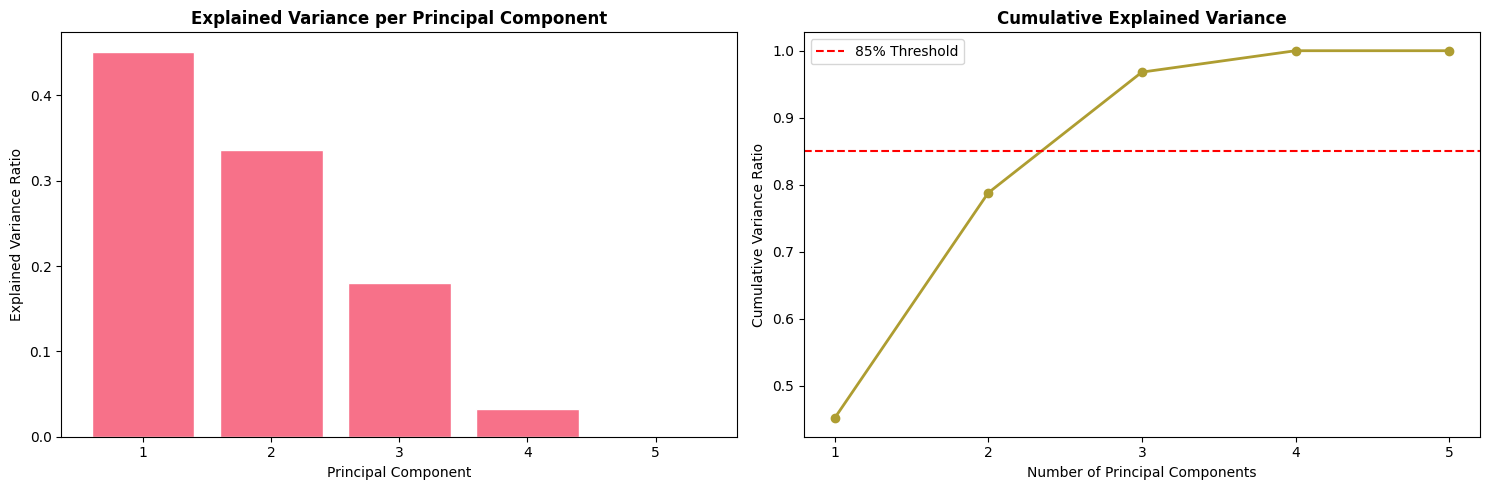

✅  Number of components to retain for ≥85% variance explained: 3
   Cumulative variance with 3 components: 0.968


In [16]:
# Apply PCA to the scaled customer feature matrix
pca = PCA()
pca.fit(X_scaled)

# Explained variance per component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot explained variance per component and cumulative variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot for explained variance per component
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, color=PALETTE[0], edgecolor="white")
ax1.set_title("Explained Variance per Principal Component", fontweight="bold")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_xticks(range(1, len(explained_variance) + 1))

# Line plot for cumulative variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color=PALETTE[1], linewidth=2)
ax2.axhline(y=0.85, color="red", linestyle="--", linewidth=1.5, label="85% Threshold")
ax2.set_title("Cumulative Explained Variance", fontweight="bold")
ax2.set_xlabel("Number of Principal Components")
ax2.set_ylabel("Cumulative Variance Ratio")
ax2.set_xticks(range(1, len(cumulative_variance) + 1))
ax2.legend()

plt.tight_layout()
plt.show()

# Determine how many components to retain for ≥85% variance explained
n_components_85 = (cumulative_variance >= 0.85).argmax() + 1
print(f"✅  Number of components to retain for ≥85% variance explained: {n_components_85}")
print(f"   Cumulative variance with {n_components_85} components: {cumulative_variance[n_components_85-1]:.3f}")

#### 26. Re-run your best clustering algorithm in PCA-reduced space. Does the silhouette score improve, worsen, or stay the same? Explain the result.

In [17]:
# Re-run K-Means in PCA-reduced space
# First, reduce to the components that capture >=85% variance
pca_reduced = PCA(n_components=n_components_85)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print(f"Reduced feature space: {X_pca_reduced.shape[1]} components (from {X_scaled.shape[1]} features)")

# Run K-Means on reduced space
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
km_pca_labels = kmeans_pca.fit_predict(X_pca_reduced)
km_pca_sil = silhouette_score(X_pca_reduced, km_pca_labels)

print(f"Original Silhouette Score (5D): {km_sil:.4f}")
print(f"PCA-Reduced Silhouette Score ({n_components_85}D): {km_pca_sil:.4f}")

# Explanation
if km_pca_sil > km_sil:
    result = "improves"
    explanation = "PCA reduced noise and multicollinearity, allowing K-Means to better separate clusters in lower-dimensional space."
elif km_pca_sil < km_sil:
    result = "worsens"
    explanation = "Dimensionality reduction may have lost some discriminative information, or the original features were already optimal."
else:
    result = "stays the same"
    explanation = "The reduction preserved the essential structure without adding or removing clustering quality."

print(f"\nThe silhouette score {result} from {km_sil:.4f} to {km_pca_sil:.4f}.")
print(f"Explanation: {explanation}")

Reduced feature space: 3 components (from 5 features)
Original Silhouette Score (5D): 0.3963
PCA-Reduced Silhouette Score (3D): 0.4035

The silhouette score improves from 0.3963 to 0.4035.
Explanation: PCA reduced noise and multicollinearity, allowing K-Means to better separate clusters in lower-dimensional space.
